# KEGG Pathway Analysis — Biological Interpretation

What it does:
1. Finds the CpG probes that best separate the 6 cancer types (ANOVA)
2. Maps those probes to gene names using the Illumina 450K annotation
3. Runs KEGG pathway enrichment — finds which biological pathways are overrepresented
4. Saves a publication-ready bar chart of top pathways


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q anndata numpy pandas scipy matplotlib seaborn gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.7 MB/s eta 0:00:00


In [15]:
SHARED_FOLDER_NAME = "multiomics-project"
from pathlib import Path
DRIVE_ROOT  = Path(f"/content/drive/MyDrive/{SHARED_FOLDER_NAME}")
RAW_DIR     = DRIVE_ROOT / "data/raw"
MANIFEST    = DRIVE_ROOT / "data/manifests/matched_samples.csv"
METH_H5AD   = DRIVE_ROOT / "data/processed/tcga_methylation.h5ad"
RESULTS_DIR = DRIVE_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_TOP_PROBES = 500  # top discriminative CpG probes to use for pathway analysis

print('Methylation h5ad exists:', METH_H5AD.exists())
print('Raw methylation folder exists:', RAW_DIR.exists())
print('Manifest exists:', MANIFEST.exists())

Methylation h5ad exists: True
Raw methylation folder exists: True
Manifest exists: True


In [16]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy import stats

print('Loading methylation data...')
adata = ad.read_h5ad(METH_H5AD)
X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
labels = adata.obs['cancer_type'].values
probe_ids = adata.var.index.astype(str).tolist()

# If the h5ad feature names are numeric positions ('0', '1', ...), recover real CpG IDs
# from the probe list used by the methylation pipeline. This keeps preprocessing untouched.
if probe_ids and not probe_ids[0].startswith('cg'):
    probe_list_path = DRIVE_ROOT / 'data/processed/probe_ids_type3.csv'
    probe_table = pd.read_csv(probe_list_path)
    cpg_cols = [c for c in probe_table.columns if probe_table[c].astype(str).str.startswith('cg').mean() > 0.5]
    if not cpg_cols:
        raise ValueError(f'Could not find CpG probe column in {probe_list_path}. Columns: {list(probe_table.columns)}')
    probe_lookup = probe_table[cpg_cols[0]].astype(str).str.strip().tolist()
    numeric_positions = pd.to_numeric(pd.Index(probe_ids), errors='coerce')
    if numeric_positions.isna().any() or int(numeric_positions.max()) >= len(probe_lookup):
        raise ValueError('Methylation h5ad has non-CpG feature IDs, but they cannot be mapped to probe_ids_type3.csv')
    probe_ids = [probe_lookup[int(i)] for i in numeric_positions]
    print(f'Recovered CpG probe IDs from {probe_list_path.name} using column: {cpg_cols[0]}')

n_variable = int((np.nanvar(X, axis=0) > 0).sum())
nonzero_fraction = float(np.mean(X != 0))
print(f'Shape: {adata.shape}')
print(f'Cancer types: {dict(zip(*np.unique(labels, return_counts=True)))}')
print(f'Number of CpG probes: {len(probe_ids)}')
print(f'Example CpG probes: {probe_ids[:5]}')
print(f'Variable probes in h5ad: {n_variable}/{X.shape[1]}')
print(f'Non-zero beta fraction in h5ad: {nonzero_fraction:.6f}')

# If the h5ad values are constant, rebuild the matrix in memory from raw files.
# This does not modify or save any preprocessing output.
if n_variable == 0:
    print('h5ad methylation values are constant. Rebuilding X in memory from raw methylation files...')
    if not MANIFEST.exists():
        raise FileNotFoundError(f'Missing manifest: {MANIFEST}')
    if not RAW_DIR.exists():
        raise FileNotFoundError(f'Missing raw data folder: {RAW_DIR}')

    manifest = pd.read_csv(MANIFEST)
    data_list = []
    label_list = []

    for row_number, row in manifest.iterrows():
        file_path = RAW_DIR / row['project'] / 'methylation' / row['meth_file_name']
        if not file_path.exists():
            print(f'Missing raw methylation file: {file_path}')
            continue

        sample_df = pd.read_csv(file_path, sep='\t', header=None, names=['probe', 'beta'])
        sample_df['probe'] = sample_df['probe'].astype(str).str.strip()
        sample_df['beta'] = pd.to_numeric(sample_df['beta'], errors='coerce')
        sample_df = sample_df.drop_duplicates('probe', keep='first').set_index('probe')
        data_list.append(sample_df.reindex(probe_ids)['beta'].to_numpy(dtype=np.float32))
        label_list.append(row['project'])

        if (len(data_list) % 50) == 0:
            print(f'Loaded {len(data_list)} raw methylation files...')

    if not data_list:
        raise ValueError('No raw methylation files were loaded. Check RAW_DIR and MANIFEST paths.')

    X = np.nan_to_num(np.stack(data_list), nan=0.0)
    labels = np.array(label_list)
    n_variable = int((np.nanvar(X, axis=0) > 0).sum())
    nonzero_fraction = float(np.mean(X != 0))
    print(f'Rebuilt in-memory methylation matrix: {X.shape}')
    print(f'Cancer types after rebuild: {dict(zip(*np.unique(labels, return_counts=True)))}')
    print(f'Variable probes after rebuild: {n_variable}/{X.shape[1]}')
    print(f'Non-zero beta fraction after rebuild: {nonzero_fraction:.6f}')
    if n_variable == 0:
        raise ValueError('Raw methylation reload still has no variable probes. Check raw file format and probe IDs.')

Loading methylation data...
Recovered CpG probe IDs from probe_ids_type3.csv using column: illumina_probe_id
Shape: (800, 49156)
Cancer types: {'TCGA-BRCA': np.int64(134), 'TCGA-COAD': np.int64(133), 'TCGA-KIRC': np.int64(133), 'TCGA-LIHC': np.int64(133), 'TCGA-LUAD': np.int64(134), 'TCGA-THCA': np.int64(133)}
Number of CpG probes: 49156
Example CpG probes: ['cg00000109', 'cg00000292', 'cg00002033', 'cg00002426', 'cg00002719']
Variable probes in h5ad: 0/49156
Non-zero beta fraction in h5ad: 0.000000
h5ad methylation values are constant. Rebuilding X in memory from raw methylation files...
Loaded 50 raw methylation files...
Loaded 100 raw methylation files...
Loaded 150 raw methylation files...
Loaded 200 raw methylation files...
Loaded 250 raw methylation files...
Loaded 300 raw methylation files...
Loaded 350 raw methylation files...
Loaded 400 raw methylation files...
Loaded 450 raw methylation files...
Loaded 500 raw methylation files...
Loaded 550 raw methylation files...
Loaded 60

In [17]:
# ANOVA: for each probe, test how different it is across 6 cancer types
# High F-statistic = this probe strongly separates cancer types
print('Running ANOVA across all probes (this takes ~5 minutes)...')

cancer_types = np.unique(labels)
f_stats = np.zeros(X.shape[1])
probe_variance = np.nanvar(X, axis=0)
variable_indices = np.where(probe_variance > 0)[0]
print(f'Variable probes available for ANOVA: {len(variable_indices)}/{X.shape[1]}')
if len(variable_indices) == 0:
    raise ValueError('No variable methylation probes available. ANOVA cannot be computed from a constant matrix.')

for i in variable_indices:
    groups = [X[labels == ct, i] for ct in cancer_types]
    f_stats[i], _ = stats.f_oneway(*groups)

# Replace NaN with 0
f_stats = np.nan_to_num(f_stats, nan=0.0)

# Top N most discriminative probes
top_indices = np.argsort(f_stats)[-N_TOP_PROBES:][::-1]
top_probe_ids = [probe_ids[i] for i in top_indices]
top_f_stats   = f_stats[top_indices]

print(f'Top probe F-statistic range: {top_f_stats[-1]:.1f} - {top_f_stats[0]:.1f}')
print(f'Example top probes: {top_probe_ids[:5]}')

Running ANOVA across all probes (this takes ~5 minutes)...
Variable probes available for ANOVA: 47199/49156
Top probe F-statistic range: 364.7 - 1654.0
Example top probes: ['cg25042226', 'cg09634469', 'cg00371195', 'cg13595556', 'cg26301689']


In [18]:
# Download Illumina 450K annotation — maps probe IDs to gene names
import urllib.request

ANNOTATION_URL = "https://raw.githubusercontent.com/chrisamiller/450k-annotation/master/HumanMethylation450_15017482_v1-2_filtered.csv"
ANNOTATION_PATH = Path("/content/450k_annotation.csv")

print('Downloading Illumina 450K annotation...')
try:
    urllib.request.urlretrieve(ANNOTATION_URL, ANNOTATION_PATH)
    annot = pd.read_csv(ANNOTATION_PATH, low_memory=False)
    print(f'Annotation loaded: {annot.shape}')
    print(f'Columns: {list(annot.columns[:10])}')
except Exception as e:
    print(f'Direct download failed ({e}), trying alternative...')
    # Alternative: use the UCSC annotation
    !wget -q -O /content/450k_annotation.csv.gz "https://zhouserver.research.chop.edu/InfiniumAnnotation/20180909/HM450/HM450.hg38.manifest.tsv.gz"
    annot = pd.read_csv('/content/450k_annotation.csv.gz', sep='\t', low_memory=False)
    print(f'Alternative annotation loaded: {annot.shape}')

Direct download failed (HTTP Error 404: Not Found), trying alternative...
Alternative annotation loaded: (485577, 57)


In [20]:
# Map probe IDs to gene names
# Annotation files differ, so choose columns by known names first, then by content.
probe_candidates = ['IlmnID', 'Name', 'Probe_ID', 'probeID', 'probe_id', 'ID']
gene_candidates = [
    'UCSC_RefGene_Name', 'UCSC_REFGENE_NAME', 'UCSC_RefGene_Name.hg19',
    'gene', 'Gene', 'Gene_Name', 'gene_name', 'geneNames', 'genes', 'Symbol'
]

probe_col = next((c for c in probe_candidates if c in annot.columns), None)
if probe_col is None:
    cpg_like_cols = [c for c in annot.columns if annot[c].astype(str).str.startswith('cg').mean() > 0.5]
    probe_col = cpg_like_cols[0] if cpg_like_cols else annot.columns[0]

gene_col = next((c for c in gene_candidates if c in annot.columns), None)
if gene_col is None:
    gene_like_cols = [c for c in annot.columns if 'gene' in c.lower() and 'group' not in c.lower()]
    gene_col = gene_like_cols[0] if gene_like_cols else None
if gene_col is None:
    raise ValueError(f'Could not find a gene annotation column. Columns: {list(annot.columns)}')

print(f'Using probe column: {probe_col}')
print(f'Using gene column : {gene_col}')

def clean_probe_id(value):
    value = str(value).strip()
    return value.split('.')[0]

annot_clean = annot[[probe_col, gene_col]].copy()
annot_clean.columns = ['probe_id', 'gene_name']
annot_clean['probe_id'] = annot_clean['probe_id'].map(clean_probe_id)
annot_clean['gene_name'] = annot_clean['gene_name'].astype(str).str.strip()
annot_clean = annot_clean[annot_clean['probe_id'].str.startswith('cg')]
annot_clean = annot_clean[~annot_clean['gene_name'].isin(['', 'nan', 'NA', 'N/A', '---'])]
probe_to_gene = dict(zip(annot_clean['probe_id'], annot_clean['gene_name']))

matched_top = sum(1 for p in top_probe_ids if clean_probe_id(p) in probe_to_gene)
print(f'Probes with gene annotation: {len(probe_to_gene)}')
print(f'Top probes matched to annotation: {matched_top}/{len(top_probe_ids)}')

Using probe column: probeID
Using gene column : gene
Probes with gene annotation: 408435
Top probes matched to annotation: 461/500


In [21]:
# Get gene list from top probes
gene_list = []
probe_gene_pairs = []

for probe_id, f_stat in zip(top_probe_ids, top_f_stats):
    raw_gene = probe_to_gene.get(probe_id, '')
    if not raw_gene:
        continue
    # Some probes map to multiple genes separated by ';'
    for gene in str(raw_gene).split(';'):
        gene = gene.strip()
        if gene and gene != 'NA':
            gene_list.append(gene)
            probe_gene_pairs.append({'probe_id': probe_id, 'gene': gene, 'f_statistic': f_stat})

gene_list = list(set(gene_list))  # unique genes

# Save top probes table
df_probes = pd.DataFrame(probe_gene_pairs)
df_probes.to_csv(RESULTS_DIR / 'top_discriminative_probes.csv', index=False)

print(f'Unique genes from top {N_TOP_PROBES} probes: {len(gene_list)}')
print(f'Example genes: {gene_list[:10]}')

Unique genes from top 500 probes: 480
Example genes: ['HNF1A', 'PHGR1', 'SERPIND1', 'NUP210L', 'TRAF3', 'RABAC1', 'RP11-546B15.1', 'KDM2B', 'RP5-881L22.5', 'FBXL19']


In [22]:
# Run KEGG pathway enrichment
import gseapy as gp

print('Running KEGG enrichment...')
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets='KEGG_2021_Human',
    organism='human',
    outdir=None,
    cutoff=0.05
)

results = enr.results.sort_values('Adjusted P-value').head(20)
results.to_csv(RESULTS_DIR / 'kegg_results.csv', index=False)

print(f'Top enriched pathways:')
for _, row in results.head(10).iterrows():
    print(f"  {row['Term'][:60]:<60} p={row['Adjusted P-value']:.4f}")

Running KEGG enrichment...
Top enriched pathways:
  Complement and coagulation cascades                          p=0.0000
  Thyroid hormone synthesis                                    p=0.0101
  Maturity onset diabetes of the young                         p=0.0301
  TNF signaling pathway                                        p=0.1013
  Steroid hormone biosynthesis                                 p=0.1514
  Adrenergic signaling in cardiomyocytes                       p=0.1514
  Carbohydrate digestion and absorption                        p=0.1977
  Bile secretion                                               p=0.1977
  Cholesterol metabolism                                       p=0.2017
  Pertussis                                                    p=0.2627


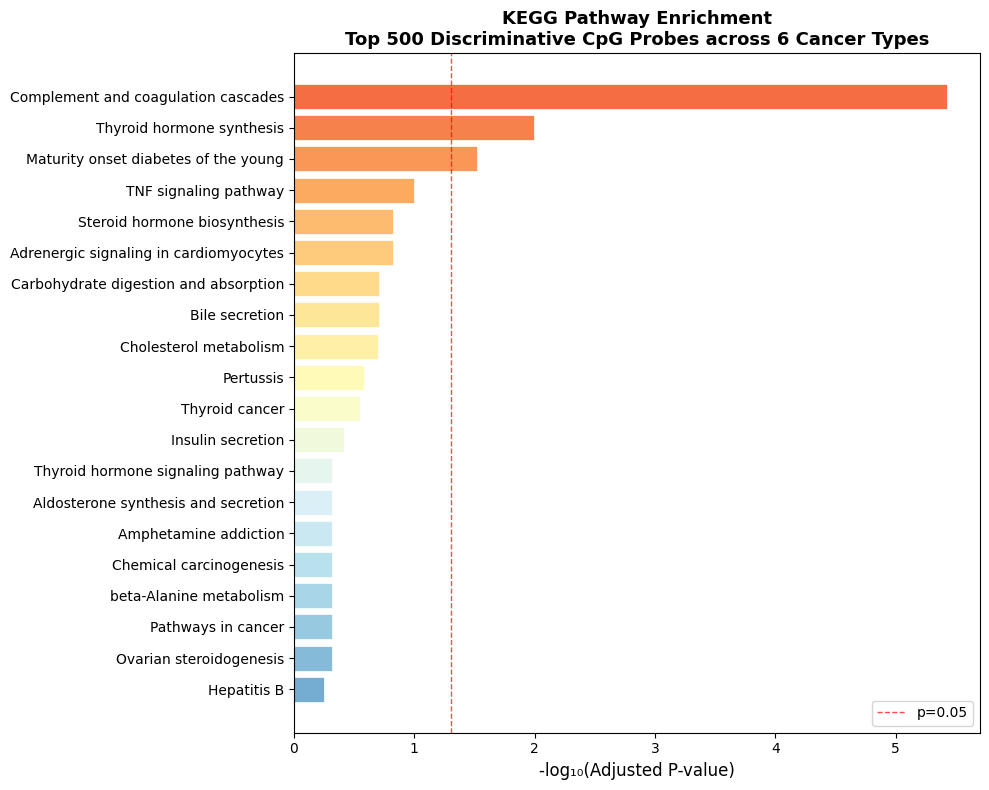

Saved to Drive!


In [23]:
# Publication-ready KEGG bar chart
import matplotlib.pyplot as plt
import numpy as np

top20 = results.head(20).copy()
top20['-log10(padj)'] = -np.log10(top20['Adjusted P-value'].clip(1e-10))
top20 = top20.sort_values('-log10(padj)')

# Clean pathway names (remove 'KEGG_' prefix if present)
top20['Term'] = top20['Term'].str.replace(r'^KEGG_', '', regex=True).str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top20['Term'],
    top20['-log10(padj)'],
    color=plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(top20))),
    edgecolor='white', linewidth=0.5
)
ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=1, alpha=0.7, label='p=0.05')
ax.set_xlabel('-log₁₀(Adjusted P-value)', fontsize=12)
ax.set_title(
    f'KEGG Pathway Enrichment\nTop {N_TOP_PROBES} Discriminative CpG Probes across 6 Cancer Types',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'kegg_top_pathways.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive!')

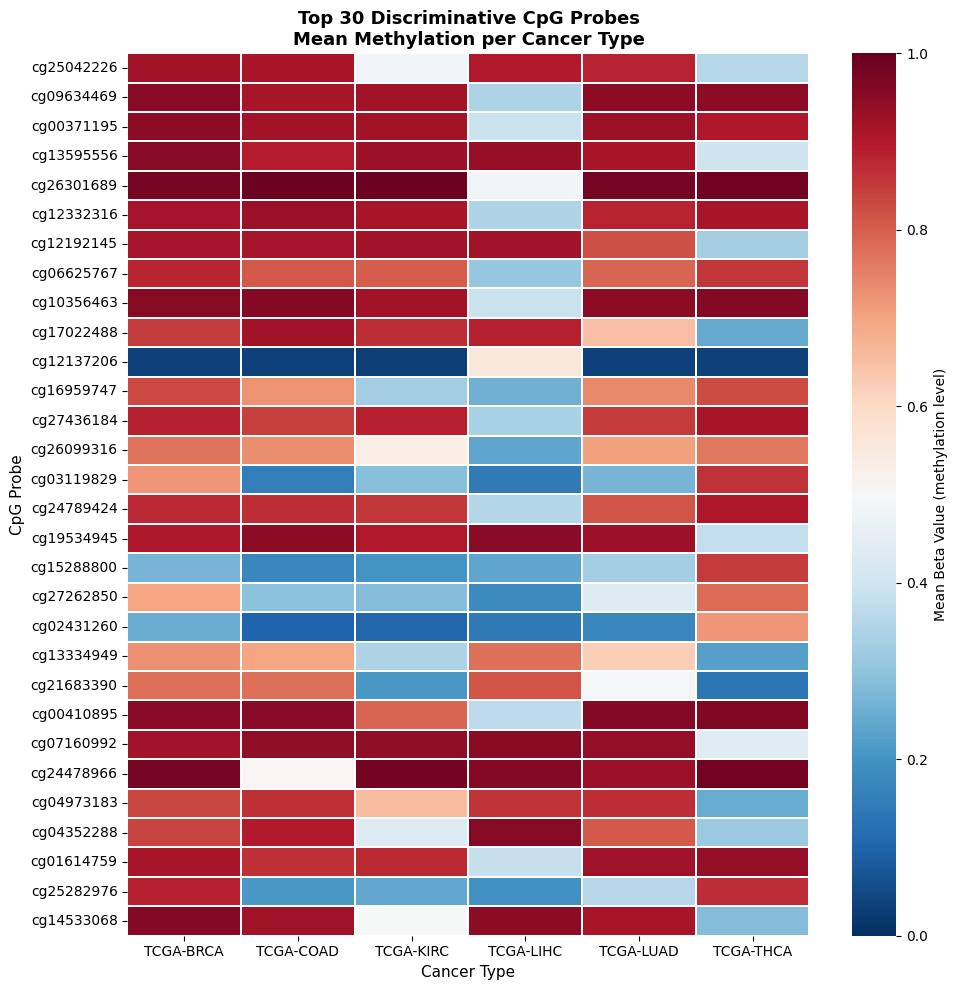


All done! Files saved to Drive/results/:
  kegg_top_pathways.png       — share with group
  methylation_heatmap.png     — share with group
  kegg_results.csv            — full enrichment table
  top_discriminative_probes.csv — top 500 probes with gene names


In [24]:
# Also: show per-cancer-type methylation heatmap for top 30 probes
import seaborn as sns

top30_idx   = top_indices[:30]
top30_ids   = [probe_ids[i] for i in top30_idx]
X_top30     = X[:, top30_idx]

# Mean beta value per cancer type per probe
heatmap_data = pd.DataFrame(
    {ct: X_top30[labels == ct].mean(axis=0) for ct in np.unique(labels)},
    index=[f'{p[:10]}...' if len(p) > 10 else p for p in top30_ids]
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r', center=0.5, vmin=0, vmax=1,
    ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Mean Beta Value (methylation level)'}
)
ax.set_title('Top 30 Discriminative CpG Probes\nMean Methylation per Cancer Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cancer Type', fontsize=11)
ax.set_ylabel('CpG Probe', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'methylation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll done! Files saved to Drive/results/:')
print('  kegg_top_pathways.png       — share with group')
print('  methylation_heatmap.png     — share with group')
print('  kegg_results.csv            — full enrichment table')
print('  top_discriminative_probes.csv — top 500 probes with gene names')